# Spam Email Detection Using Naive Bayes Classifier

## First we check whether we are in correct directory or not

In [74]:
!ls

 auto_commit.sh   README.ipynb	 report.tex
 code.ipynb	  README.md	 requirements.txt
 emails.csv	  report.pdf	'SPAM Email Dataset.zip'


## Unzip the file out

In [75]:
# !unzip 'SPAM Email Dataset.zip'

## Counting lines to see how many we have to work with

In [76]:
!wc -l emails.csv

5729 emails.csv


## Library importing for python works

In [77]:
import pandas as pd
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.metrics import classification_report, accuracy_score

import matplotlib.pyplot as plt

## Read the data from the file to program memory

In [78]:
df = pd.read_csv('emails.csv')
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


## Downloading NLTL - Natural Language Tool Kit for Language processing

In [79]:
# Download necessary NLTK datasets (run these once)
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /home/sadman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/sadman/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Preprocessor

In [80]:
# Copied from the internet - learn later
def preprocess_spam(text):
    # 2. Clean: Remove non-letters & lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    
    # 3. Tokenize: Split into words
    words = text.split()
    
    # 4. Lemmatize & Remove Stopwords
    # Converts 'winning' -> 'win', 'prizes' -> 'prize'
    clean_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(clean_words)

# Example output:
# "Congratulations! You are winning a free prize!" 
# -> "congratulation win free prize"

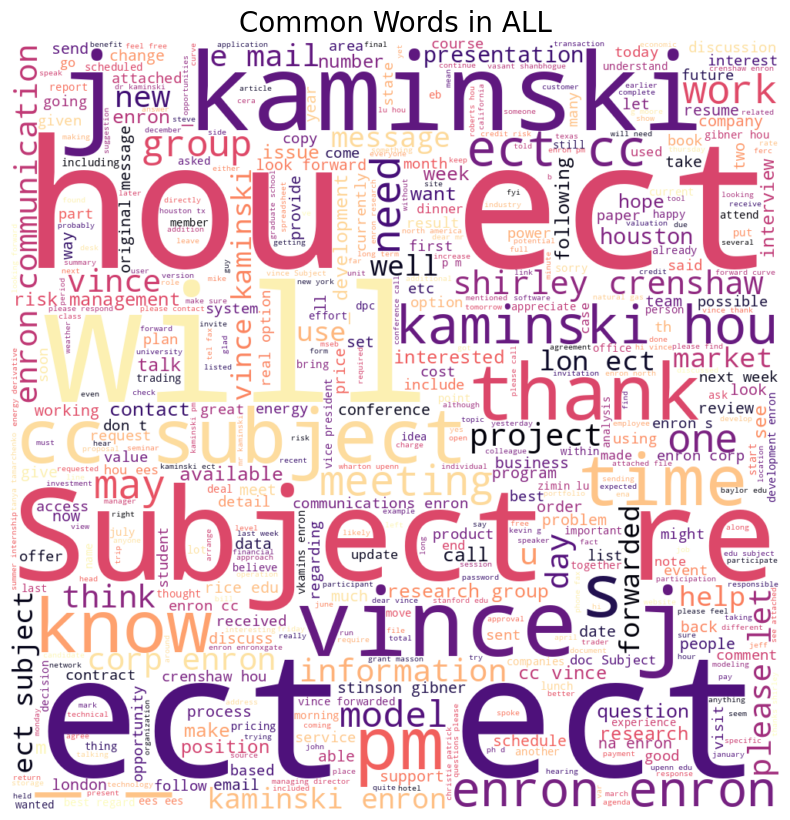

In [ ]:
from wordcloud import WordCloud

def show_wordcloud(data, title):
    text = " ".join(t for t in data)
    wordcloud = WordCloud(width=1000, height=1000, background_color='white', 
                          max_words=500, colormap='magma').generate(text)
    plt.figure(figsize=(10, 10))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

show_wordcloud(df[df['spam'] == 0]['text'], "Common Words in ALL")
show_wordcloud(df[df['spam'] == 1]['text'], "Common Words in Spam")
show_wordcloud(df['text'], "Common Words in Not Spam")

## Preprocessing 
1. Making the string lowercase since there is not a single non english words there
2. Counting how large the each mail is
3. Counting how many words are there in each message

In [ ]:
data = []
l = len(df)
spam = 0
not_spam = 0

for i in range(0, l):
    mp = {}
    mp["text"]  = preprocess_spam(df["text"][i])
    mp["spam"]  = df["spam"][i]
    mp["words"] = mp["text"].split()
    mp["len"]   = len(df["text"][i])
    mp["wc"] = len(mp["words"])
    data.append(mp)
    spam += mp["spam"]
not_spam = l - spam
print(f"Emails    : {l}")
print(f"Spam      : {spam}")
print(f"Not pam   : {not_spam}")

In [ ]:
data = pd.DataFrame(data)
data

In [ ]:
from wordcloud import WordCloud

def show_wordcloud(data, title):
    text = " ".join(t for t in data)
    wordcloud = WordCloud(width=1920, height=1080, background_color='white', 
                          max_words=50, colormap='magma').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

show_wordcloud(df[df['spam'] == 0]['text'], "Common Words in ALL")
show_wordcloud(df[df['spam'] == 1]['text'], "Common Words in Spam")
show_wordcloud(df['text'], "Common Words in Not Spam")

## Tokenization

In [ ]:
# Initialize Vectorizer
tfidf = TfidfVectorizer(max_features=5000) # Limit features to save memory
# tfidf = TfidfVectorizer()

# Transform the 'text' column
X = tfidf.fit_transform(df['text']).toarray() # GaussianNB requires a dense array
y = df['spam']

X[0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

mnb = MultinomialNB()
mnb.fit(X_train, y_train)

bnb = BernoulliNB()
# Bernoulli works best if you tell it to treat any positive count as "present"
bnb.fit(X_train, y_train)

cnb = ComplementNB()
cnb.fit(X_train, y_train)

In [ ]:
y_pred = gnb.predict(X_test)
print(f"Gaussian NB Accuracy: {accuracy_score(y_test, y_pred)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


y_pred_mnb = mnb.predict(X_test)
print(f"Multinomial NB Accuracy: {accuracy_score(y_test, y_pred_mnb)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mnb))


y_pred_bnb = bnb.predict(X_test)
print(f"Bernoulli NB Accuracy: {accuracy_score(y_test, y_pred_bnb)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bnb))

y_pred_cnb = cnb.predict(X_test)
print("Categorical NB Accuracy:", accuracy_score(y_test, y_pred_cnb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnb))